## How to get ROT_QUAT, POS and ROAD IDs:
For Road IDs, run the cell above and it will load filter all drivable roads, plotting each one. From there, decide which routes you would like to use. 
IMPORTANT: Keep the game running as the IDs change everytime you re-run the game.

For ROT_QUAT and POS you will have to go in game and figure out what location suites you best. The simplest approach is to run the game normally and see where you want to start.
Once you have that, run these commands in the game console (Press ~ to open console):
```lua 
local veh = be:getPlayerVehicle(0)
print(veh:getPosition())
print(veh:getRotation())
```

This returns the POS and ROT_QUAT

In [1]:
import pandas as pd
from beamngpy import BeamNGpy, Scenario, Vehicle
import json
import matplotlib.pyplot as plt
from pathlib import Path
import math

In [ ]:
def start_game(POS=(487.2511560303965, 178.73033832392775, 131.99757022794734), ROT_QUAT=(-0.008836166001856327, -0.009025749750435352, -0.7026769518852234, 0.7113969922065735)):
    path = Path("../../BeamNG")
    
    bng = BeamNGpy("localhost", 25252, path)
    bng.open()

    scenario = Scenario("automation_test_track", "beamngpy_feature_overview")
    ego = Vehicle("ego", model="etk800", part_config='vehicles/etk800/846x_ttsport_plus_DCT.pc', color="Blue", license="PYTHON")
    scenario.add_vehicle(
        ego, pos=POS, rot_quat=ROT_QUAT 
    )
    scenario.make(bng)

    bng.scenario.load(scenario)
    bng.scenario.start()
    return bng

def filter_data():
    df = pd.read_json('file.txt')
    df_t = df.T
    df_t = df_t[df_t['drivability'] != '-1']
    roads = list(df_t.index)
    return roads

def plot_roads(bng):
    all_roads = bng.scenario.get_roads()
    with open('file.txt', 'w') as file:
        file.write(json.dumps(all_roads))

    roads = filter_data()
    n = len(roads)

    # Figure out a grid shape close to square
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axs = axs.flatten()

    for i, rid in enumerate(roads):
        edges = bng.scenario.get_road_edges(rid)
        xs = [p['middle'][0] for p in edges]
        ys = [p['middle'][1] for p in edges]

        ax = axs[i]
        ax.plot(xs, ys, marker='o', markersize=2)
        ax.plot(xs[0], ys[0], marker='^', color='green', markersize=8)   # start
        ax.plot(xs[-1], ys[-1], marker='s', color='red', markersize=8)   # end
        ax.set_title(rid, fontsize=8)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=6)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

c:\Users\Baljot\anaconda3\envs\tutorial\Lib\site-packages\beamngpy\api\beamng\scenario.py:313: UserWarning: Function get_roads() is deprecated, use get_road_network() instead.
  create_warning(


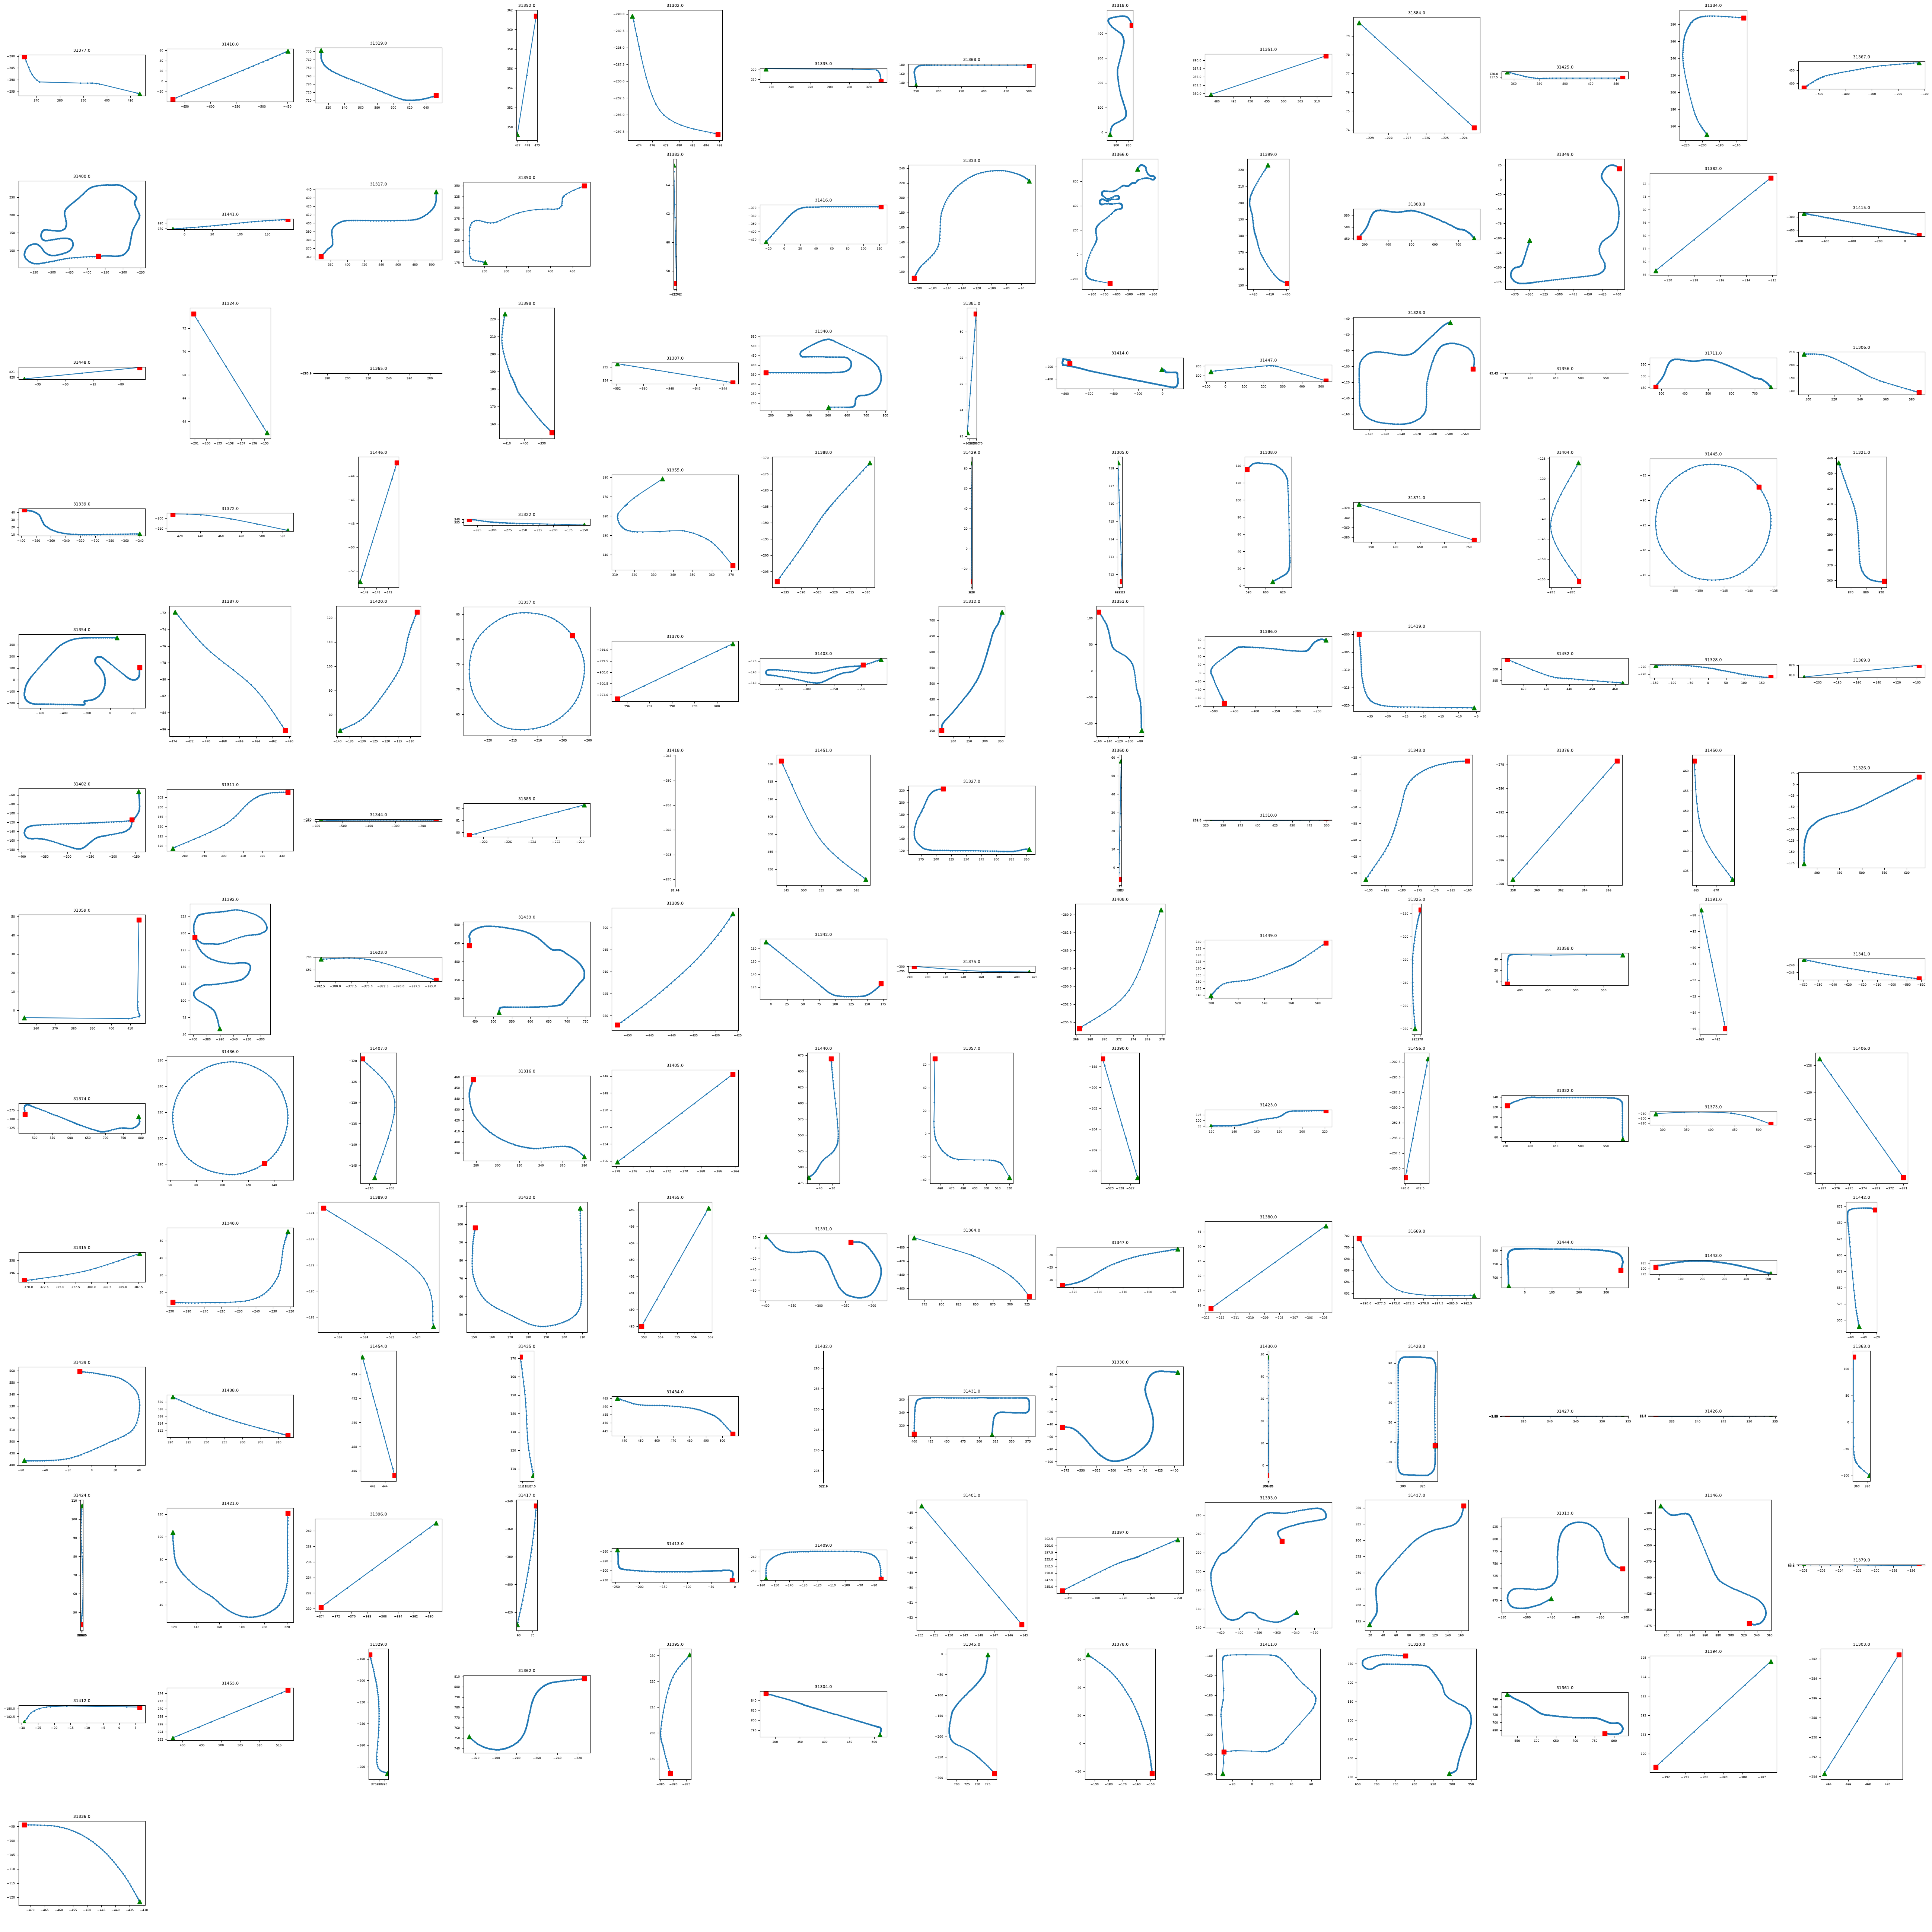

In [ ]:
bng = start_game()
plot_roads(bng)

In [ ]:
selected_ids = ['31340.0', '31354.0'] # train, test/validate - test will be the entire lap 
name = ['train', 'validate']
SETTINGS = [(-0.008836166001856327, -0.009025749750435352, -0.7026769518852234, 0.7113969922065735), (0.00902575, -0.00883617, 0.711397, 0.702677)] # ROT_QUAT

for i, id in enumerate(selected_ids):
    edges = bng.get_road_edges(id)
    with open(f'{name[i]}_map.txt', 'w') as f:
        f.write(json.dumps(edges))
    STNG = {'START_POS_MID': edges[0]['middle'], 'START_POS_LEFT': edges[0]['left'], 'START_POS_RIGHT': edges[0]['right'], 'ROT_QUAT': SETTINGS[i], 'END_POS_MID': edges[-1]['middle'], 'END_POS_LEFT': edges[-1]['left'], 'END_POS_RIGHT': edges[-1]['right']} 
    with open(f'{name[i]}_SETTINGS.txt', 'w') as f:
        f.write(json.dumps(STNG))
bng.close()
